# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

data_path = Path("../data/body_signal_of_smoking/data_raw.csv")


# Intial Exploration

In [2]:
df = pd.read_csv(data_path)
df.head()


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7   eyesight(right)      55692 non-null  float64
 8   hearing(left)        55692 non-null  float64
 9   hearing(right)       55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting blood sugar  55692 non-null  float64
 13  Cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  HDL                  55692 non-null 

In [4]:
df.isna().sum()

ID                     0
gender                 0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
oral                   0
dental caries          0
tartar                 0
smoking                0
dtype: int64

In [5]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,55692.0,NaN,NaN,NaN,27845.5,16077.039933,0.0,13922.75,27845.5,41768.25,55691.0
gender,55692,2,M,35401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,55692.0,NaN,NaN,NaN,44.182917,12.071418,20.0,40.0,40.0,55.0,85.0
height(cm),55692.0,NaN,NaN,NaN,164.649321,9.194597,130.0,160.0,165.0,170.0,190.0
weight(kg),55692.0,NaN,NaN,NaN,65.864936,12.820306,30.0,55.0,65.0,75.0,135.0
waist(cm),55692.0,NaN,NaN,NaN,82.046418,9.274223,51.0,76.0,82.0,88.0,129.0
eyesight(left),55692.0,NaN,NaN,NaN,1.012623,0.486873,0.1,0.8,1.0,1.2,9.9
eyesight(right),55692.0,NaN,NaN,NaN,1.007443,0.485964,0.1,0.8,1.0,1.2,9.9
hearing(left),55692.0,NaN,NaN,NaN,1.025587,0.157902,1.0,1.0,1.0,1.0,2.0
hearing(right),55692.0,NaN,NaN,NaN,1.026144,0.159564,1.0,1.0,1.0,1.0,2.0


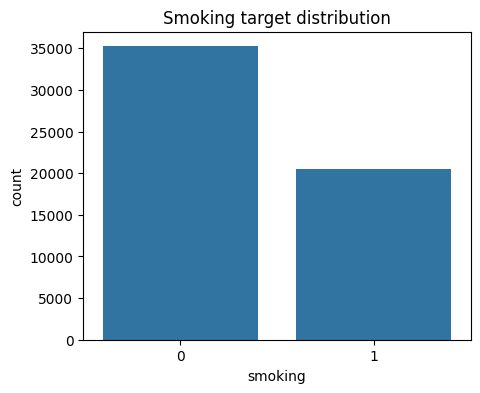

smoking
0    0.632712
1    0.367288
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="smoking")
plt.title("Smoking target distribution")
plt.show()

print(df['smoking'].value_counts(normalize=True))

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['gender', 'oral', 'tartar'], dtype='object')

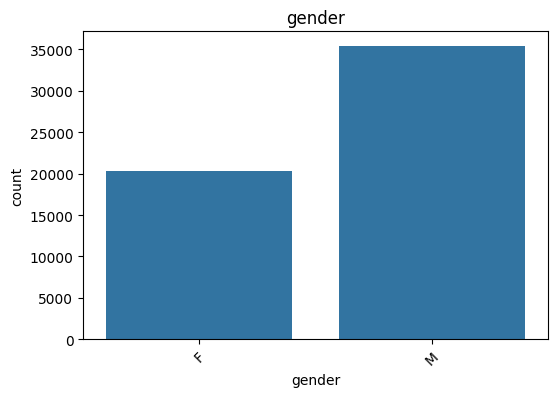

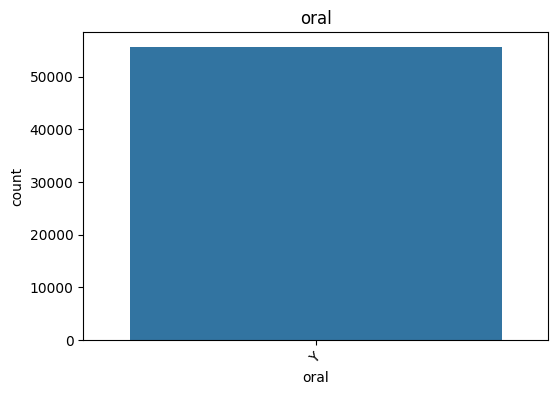

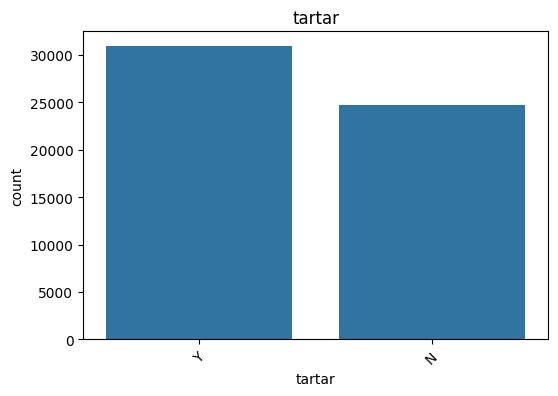

In [8]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

# Feature Engineering

In [9]:


df["ID"] = df["ID"].astype(str)
df["dental caries"] = df["dental caries"].astype(int).astype(str)
df["smoking"] = df["smoking"].astype(int).astype(str)



In [10]:
df["bmi"] = df["weight(kg)"]/((df["height(cm)"]/100)**2) # body mass index (bmi) = weight (kg) / height (m)^2
df["avg_eyesight"] = (df["eyesight(left)"]+df["eyesight(right)"])/2 
df["avg_hearing"] = (df["hearing(left)"]+df["hearing(right)"])/2
df["HDL_to_LDL"] = df["HDL"]/df["LDL"] # ratio of good cholesterol
df.drop(["weight(kg)","height(cm)","eyesight(left)","eyesight(right)","hearing(left)","hearing(right)","HDL","LDL","oral"],axis=1,inplace=True) # removing columns that became redundant.
print(df.dtypes) # This will help to determine the shape of plots consisting of subplots.

ID                      object
gender                  object
age                      int64
waist(cm)              float64
systolic               float64
relaxation             float64
fasting blood sugar    float64
Cholesterol            float64
triglyceride           float64
hemoglobin             float64
Urine protein          float64
serum creatinine       float64
AST                    float64
ALT                    float64
Gtp                    float64
dental caries           object
tartar                  object
smoking                 object
bmi                    float64
avg_eyesight           float64
avg_hearing            float64
HDL_to_LDL             float64
dtype: object


In [11]:
output_path = "../data/body_signal_of_smoking/data.csv"
df.to_csv(output_path, index=False)
print(f"Saved processed dataset to {output_path}")

Saved processed dataset to ../data/body_signal_of_smoking/data.csv


# Exploratory Data Analysis (EDA)

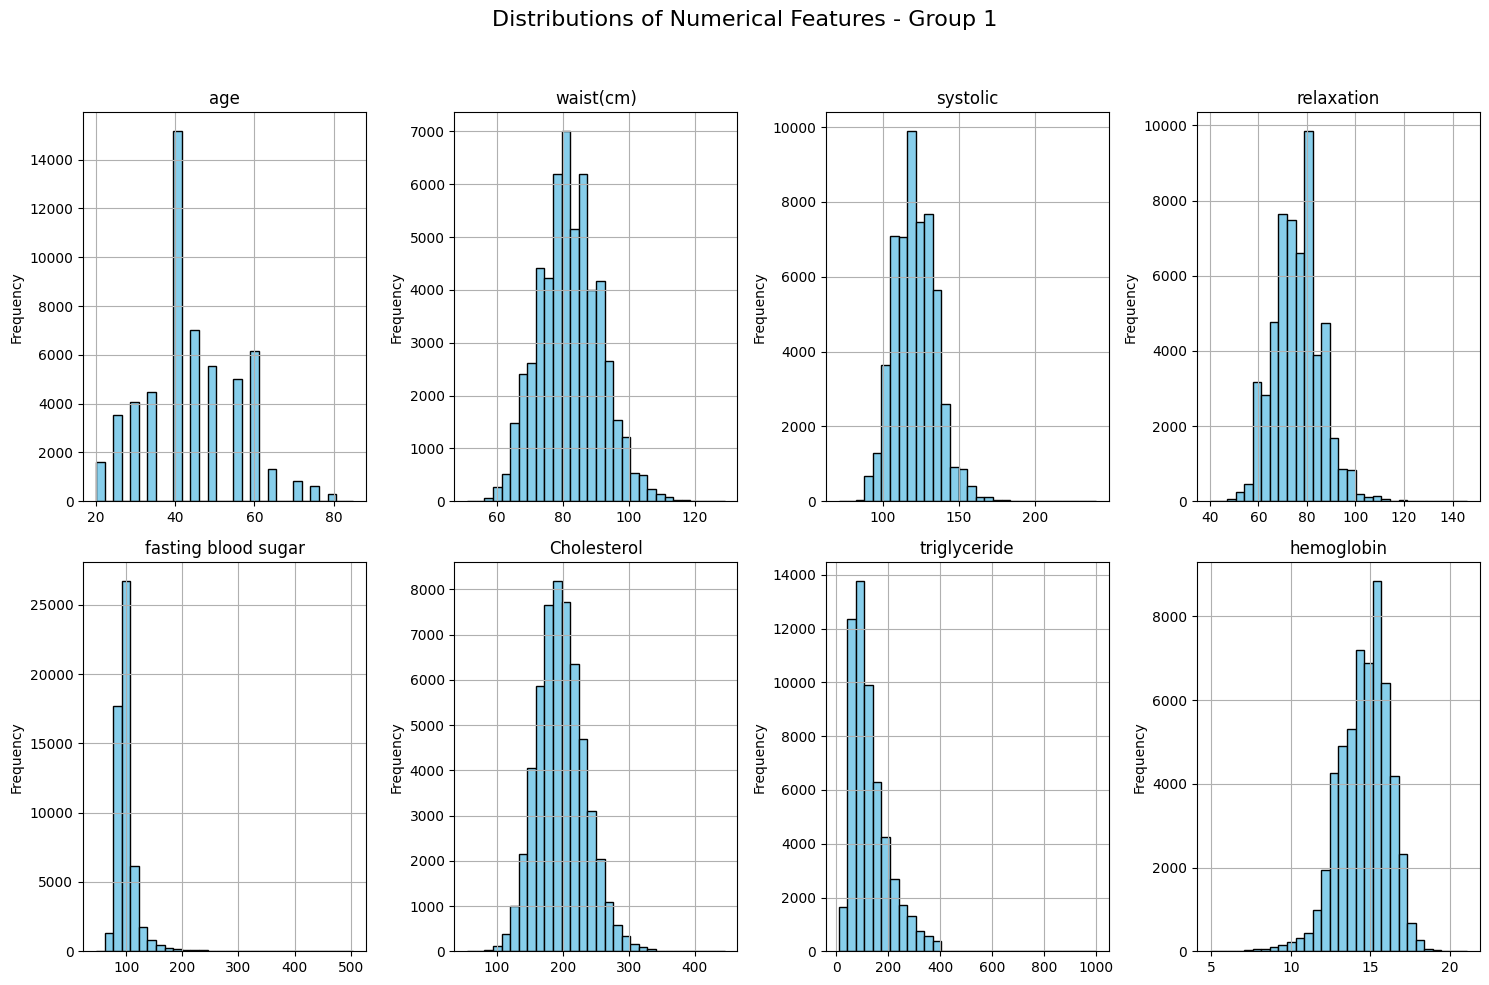

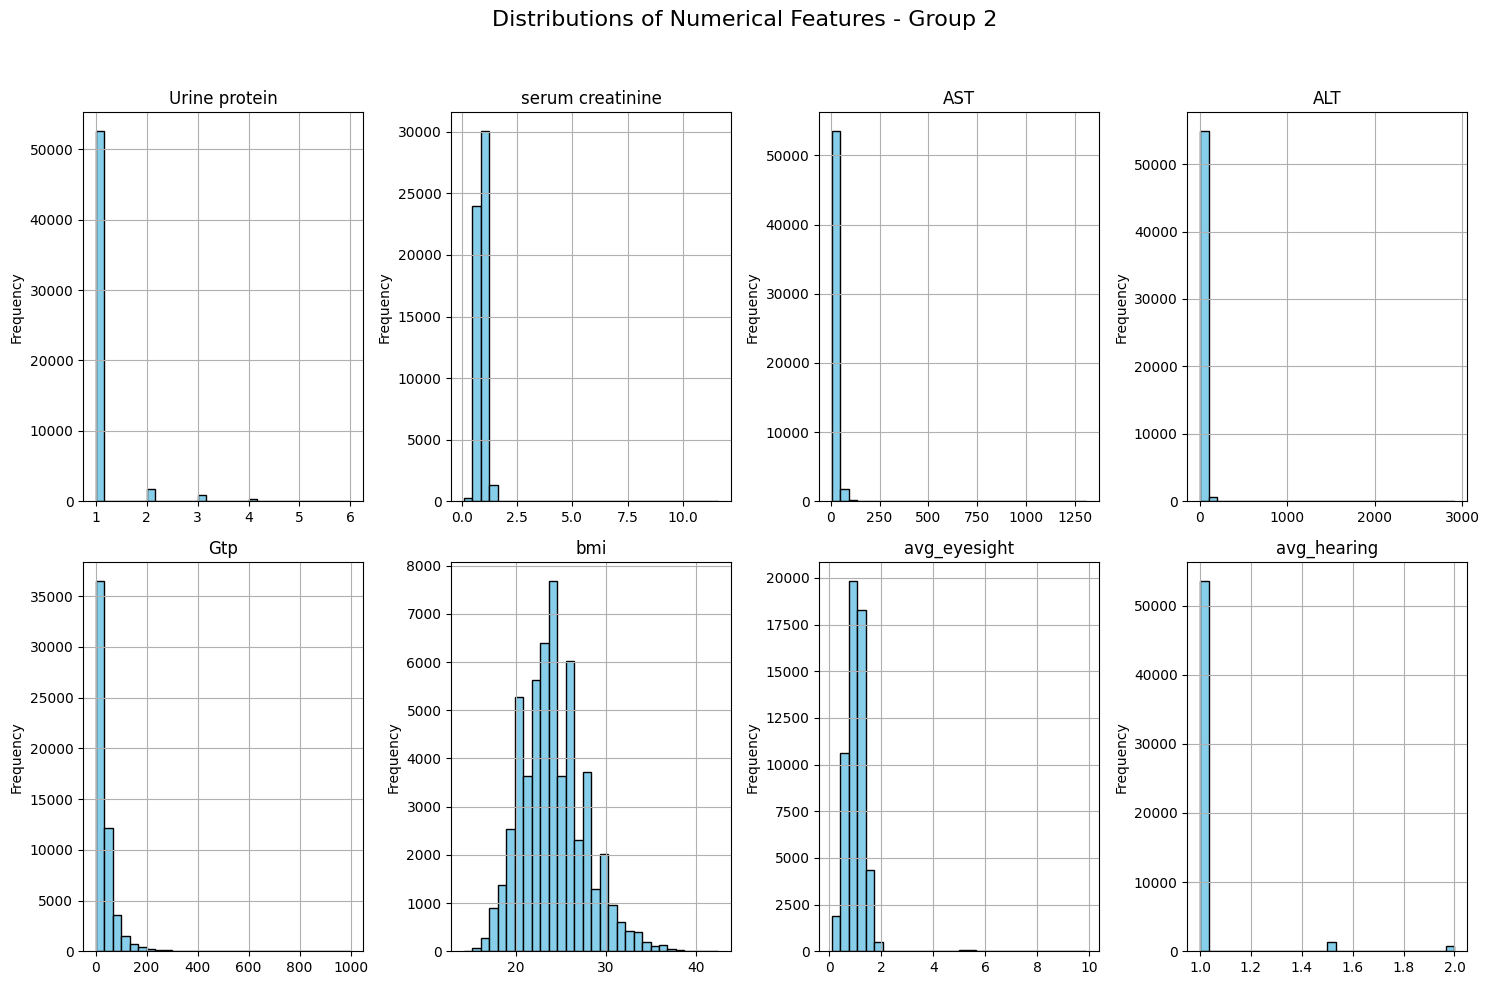

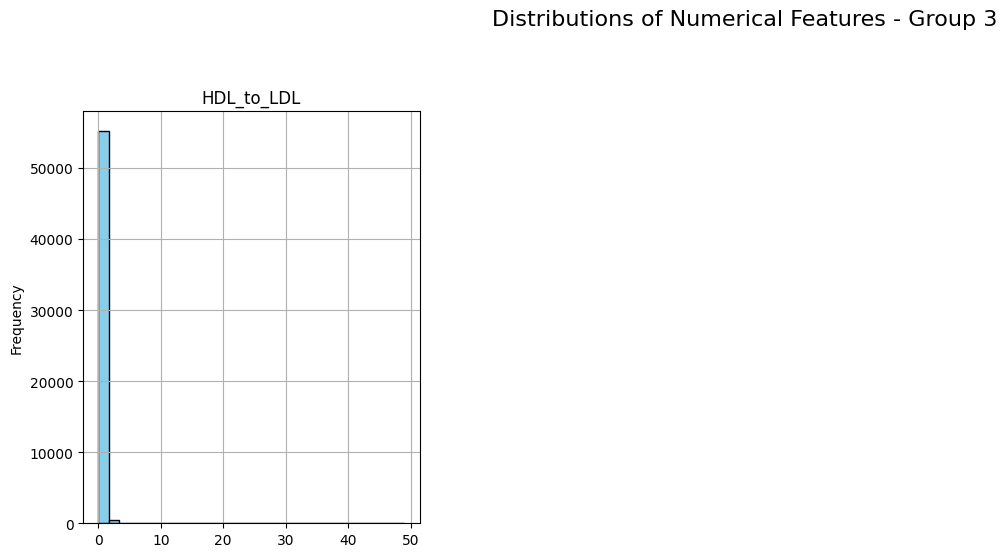

In [12]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

n = len(numeric_cols)
chunks = [numeric_cols[i:i + 8] for i in range(0, n, 8)] # 21 column will be displayed in 8-subplot plots.

for i, group in enumerate(chunks, 1):
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15,10))
    fig.suptitle(f'Distributions of Numerical Features - Group {i}', fontsize=16)
    
    for col, ax in zip(group, axes.flatten()):
        df[col].hist(ax=ax, bins=30, color='skyblue', edgecolor='black')
        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel('Frequency')

    # Empty subplot for the last grid.
    for j in range(len(group), 8):
        fig.delaxes(axes.flatten()[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Area for title
    plt.show()

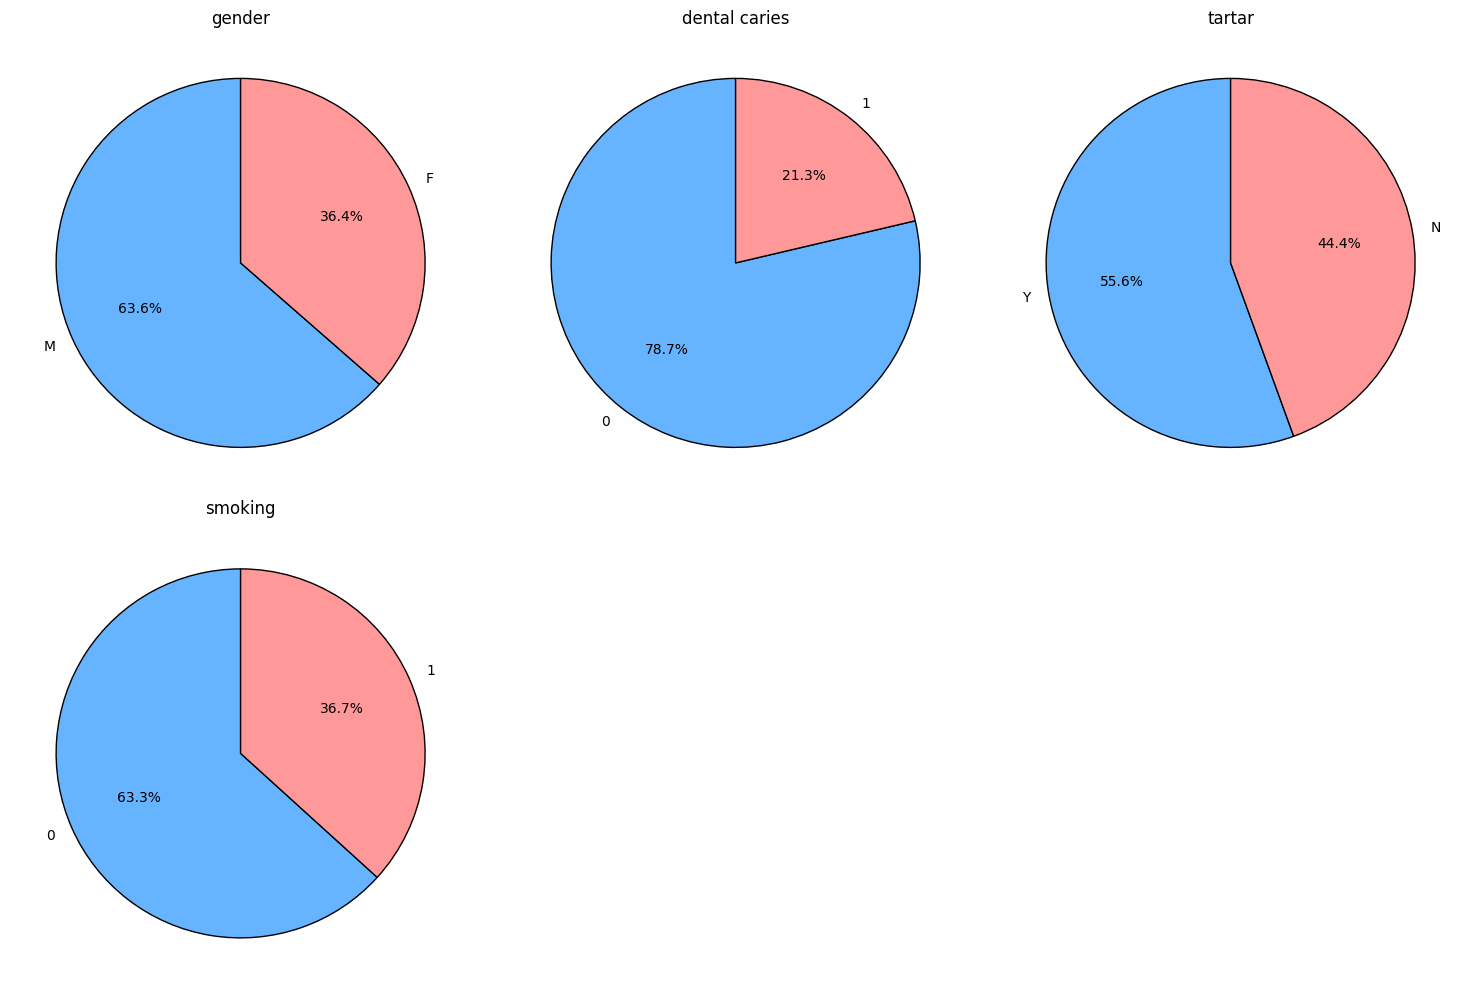

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col!="ID"]
n_cols = 3
n_rows = -(-len(categorical_cols)//n_cols)

# Step 3.2.2: Visualize the every column as a piechart
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot.pie(
        ax=axes[i],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3ff', '#ff9999'],
        wedgeprops={'edgecolor': 'black'}
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('')  

# Empty subplot for the last grid.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() 


Perform a focused numerical analysis on selected health indicators such as AST, ALT, GTP, and cholesterol ratio (HDL to LDL). The code calculates the percentage of participants falling within healthy clinical ranges for each of these variables — offering preliminary insights into the population’s general liver and cholesterol health.

In [14]:
healthy_ast = df[(df["AST"]>=10) & (df["AST"]<=40)]
ast_ratio = len(healthy_ast)/len(df)
print(f"{ast_ratio:.2%} of the participants have healthy AST values.")

healthy_alt = df[(df["ALT"]>=7) & (df["ALT"]<=56)]
alt_ratio = len(healthy_alt)/len(df)
print(f"{alt_ratio:.2%} of the participants have healthy ALT values.")

healthy_gtp = df[(df["Gtp"]>=8) & (df["Gtp"]<=61)]
gtp_ratio = len(healthy_gtp)/len(df)
print(f"{ast_ratio:.2%} of the participants have healthy GTP values.")

healthy_cholesterol = df[df["HDL_to_LDL"]>=1]
hc_ratio = len(healthy_cholesterol)/len(df)
print(f"{hc_ratio:.2%} of the participants have healthy cholesterol values.")

92.80% of the participants have healthy AST values.
93.26% of the participants have healthy ALT values.
92.80% of the participants have healthy GTP values.
5.94% of the participants have healthy cholesterol values.


# Deep Dive

## Correlation Matrix

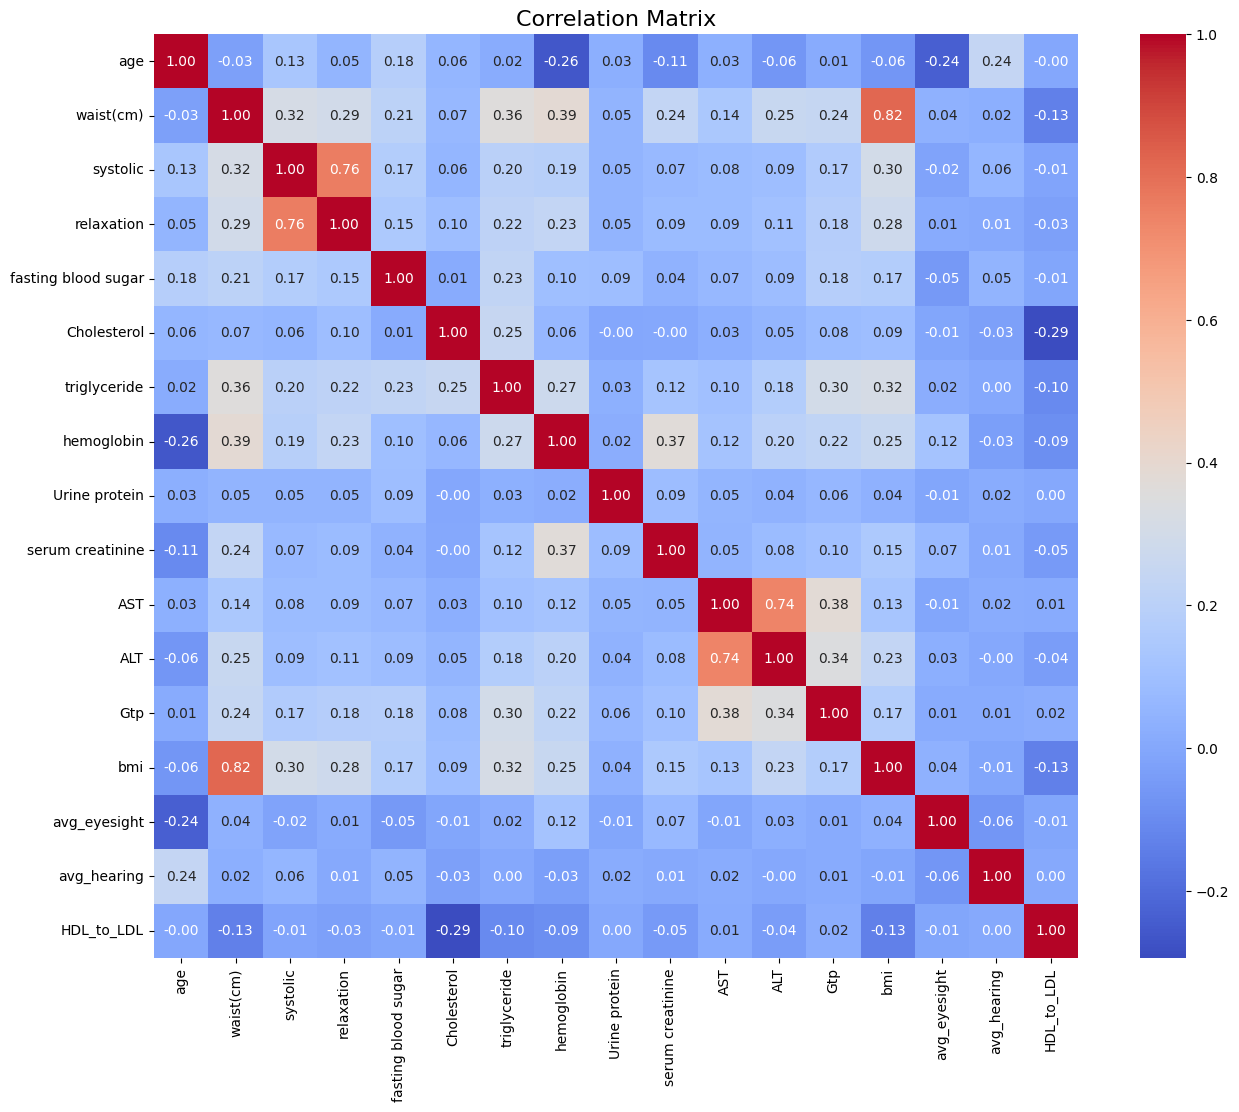

In [15]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()


This heat map shows that:

    BMI and waist width are strongly and positively correlated (that is why it is better to derive BMI column instead of weight).
    AST and ALT are significantly and positively correlated.



## Group-Based Analysis

We then divide the dataset into subgroups to visualize the distributions of both numerical and categorical features:

### Gender-Based Analysis (Male vs Female)

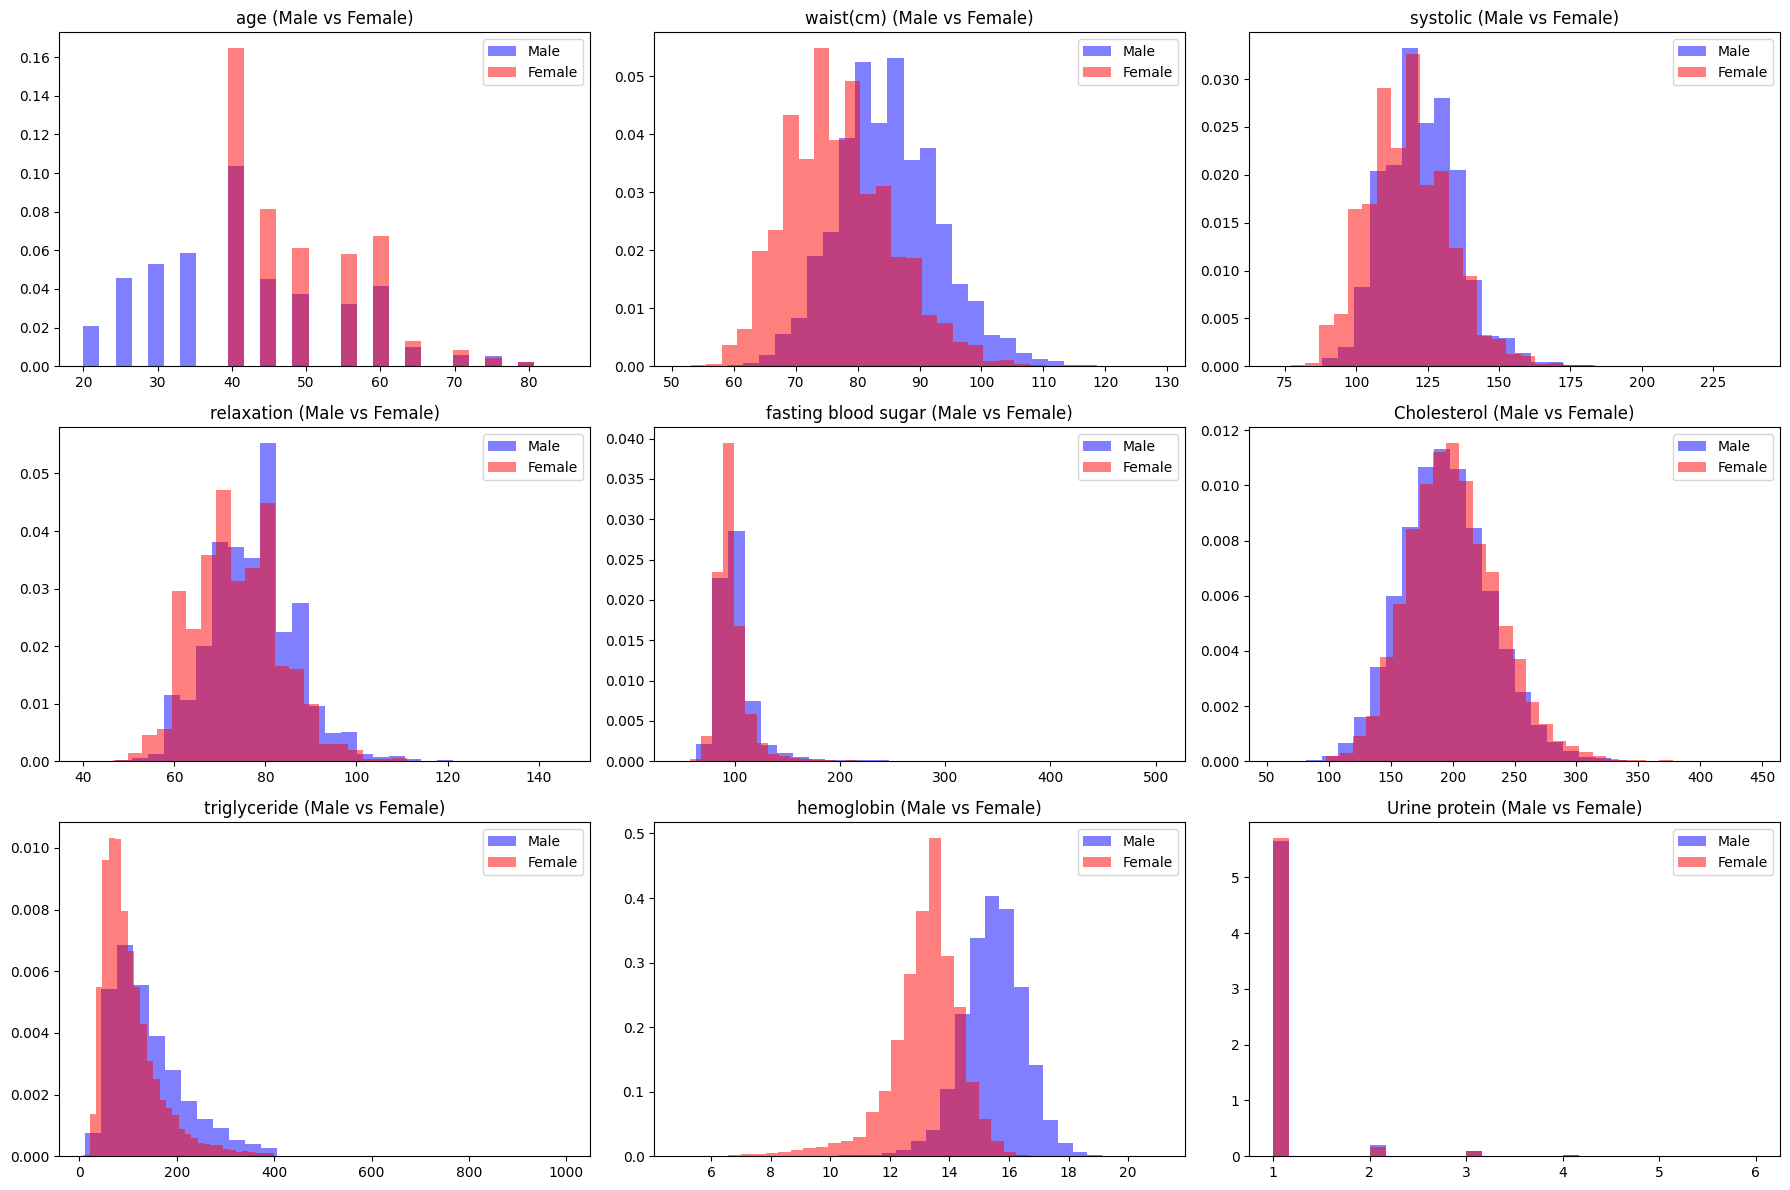

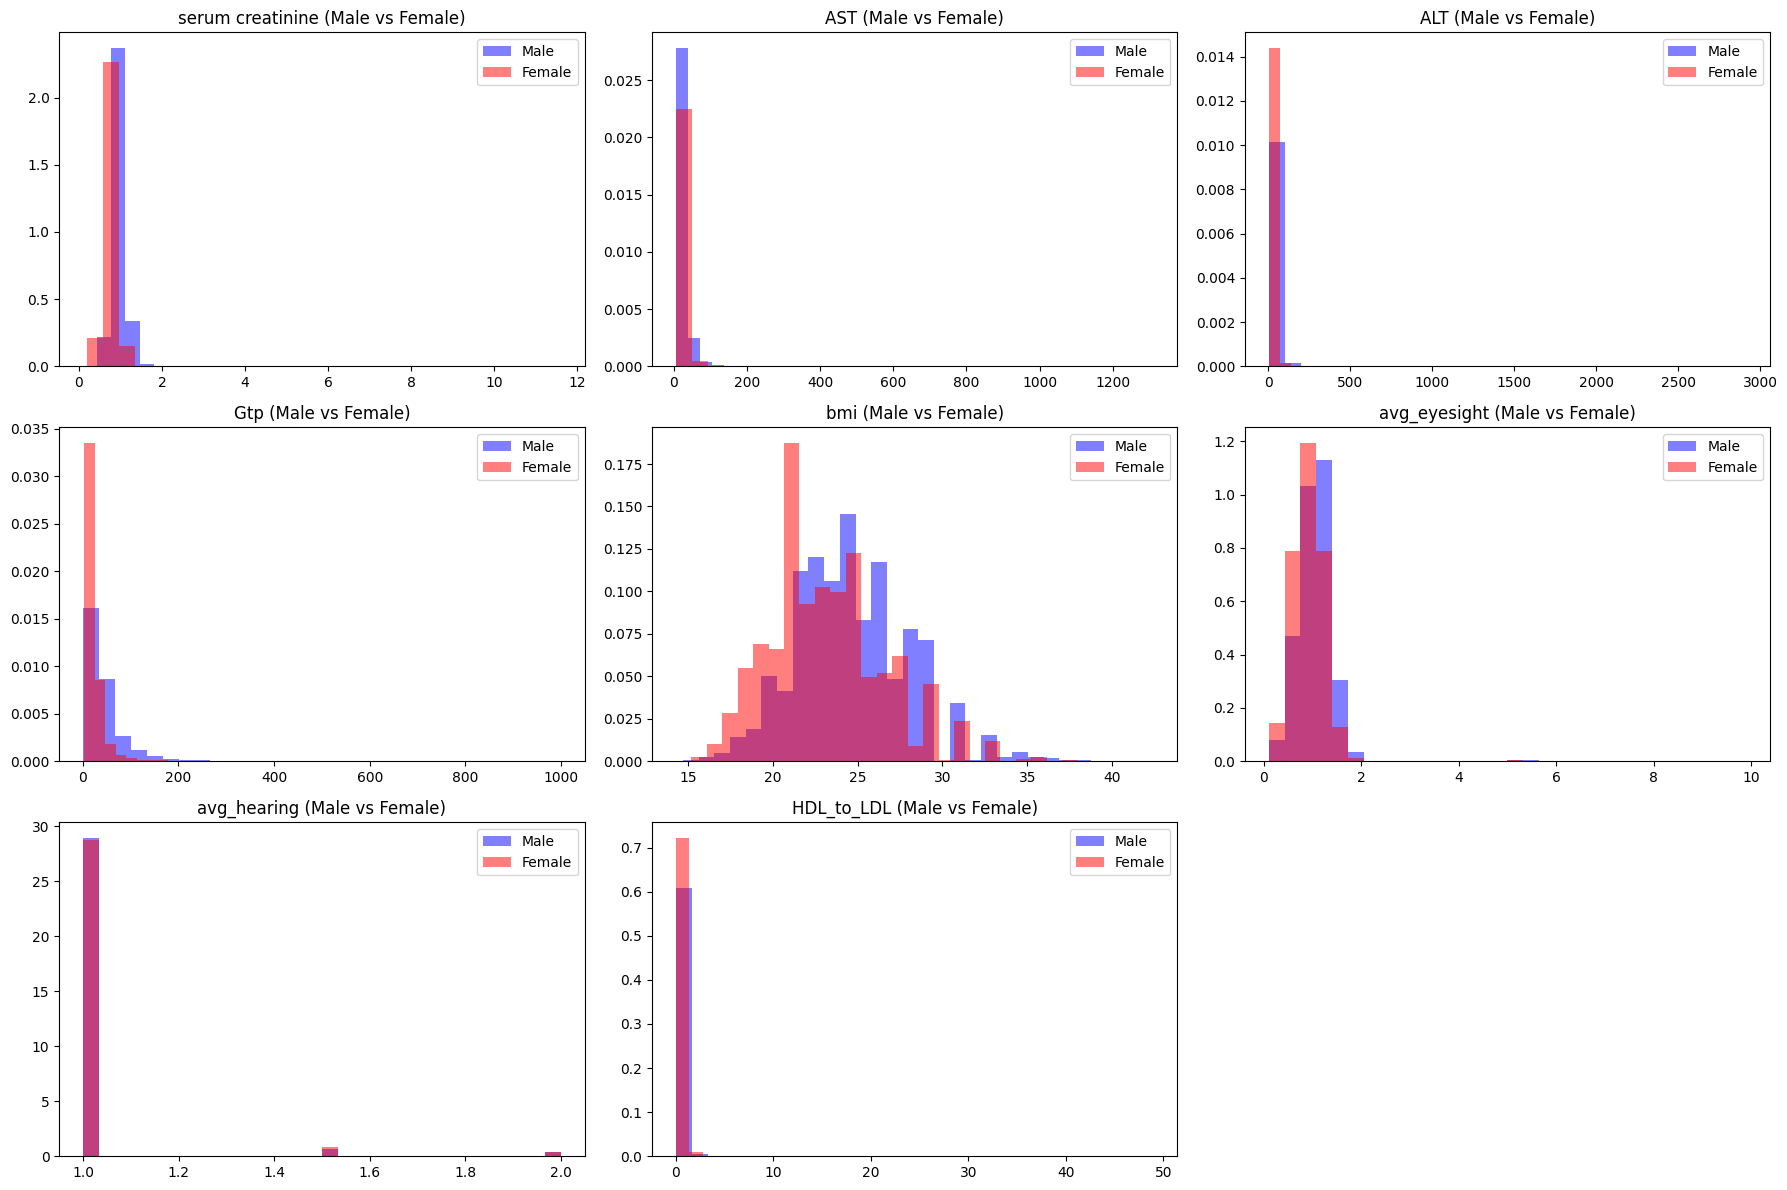

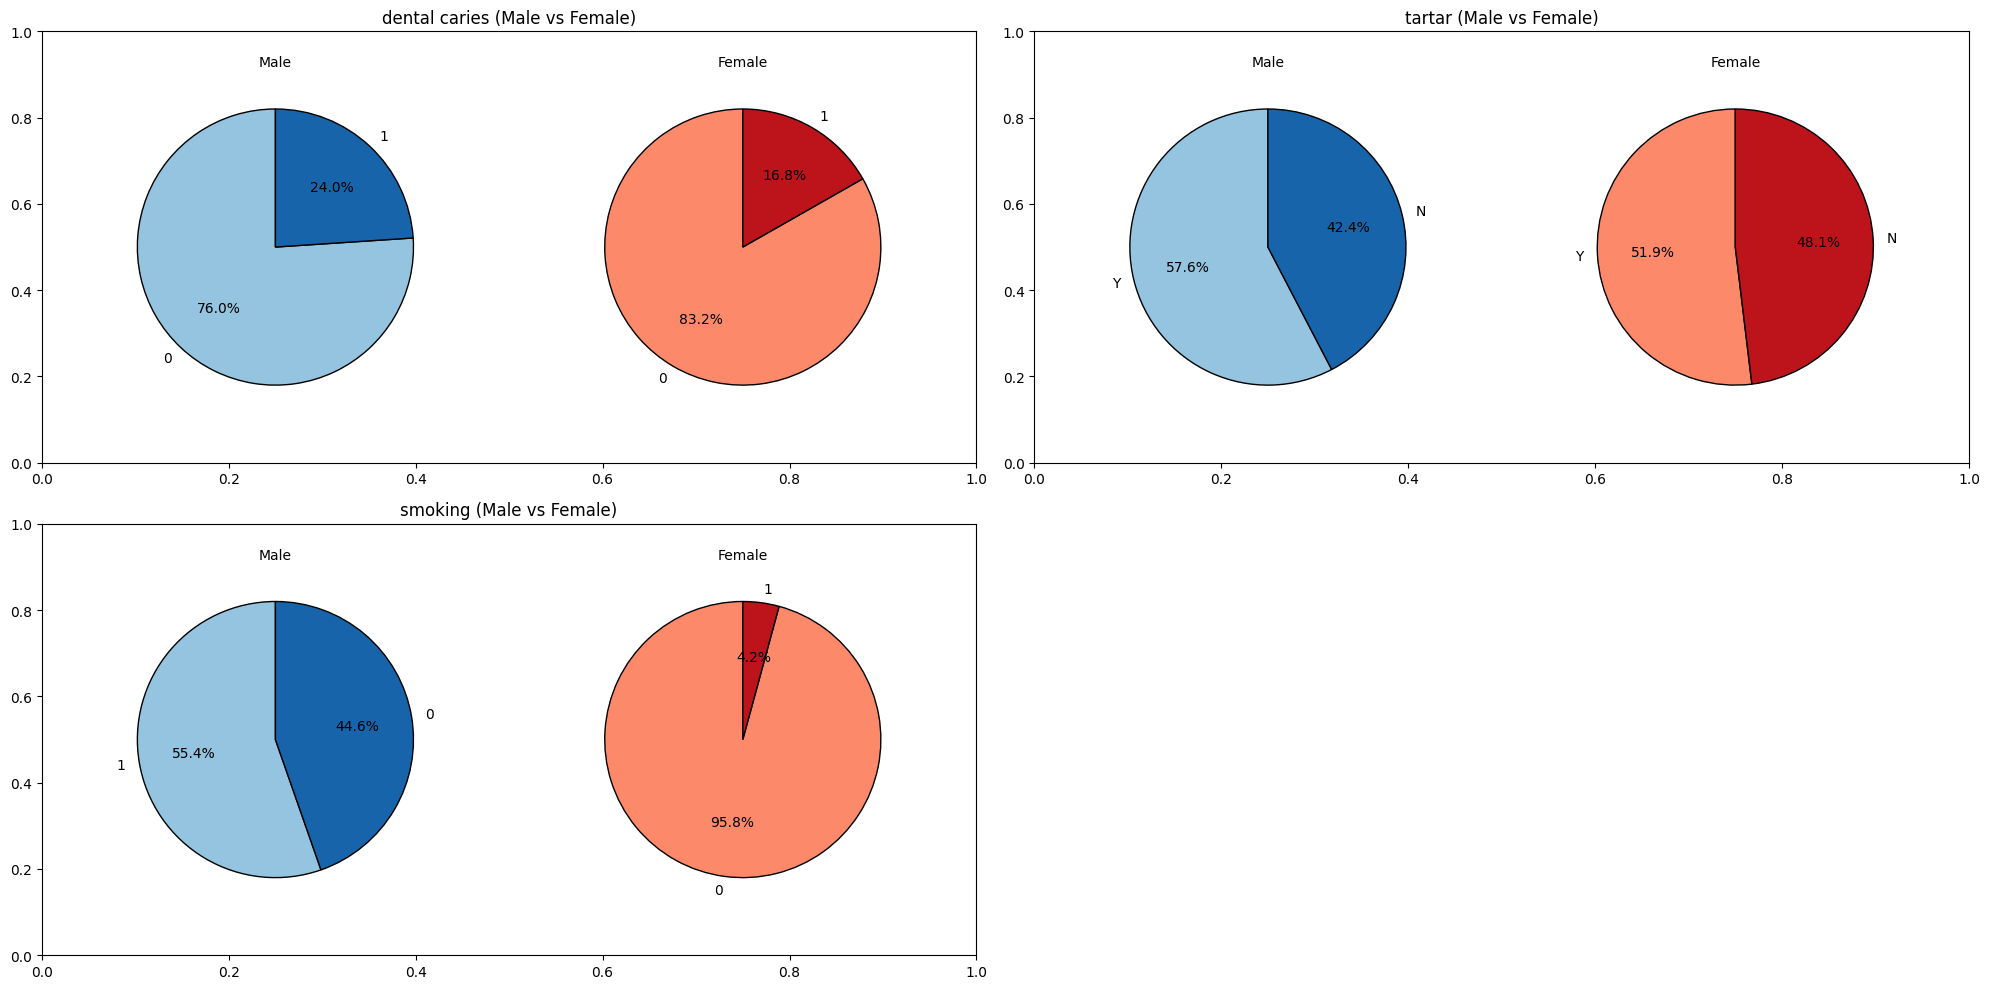

In [16]:
male = df[df["gender"]=="M"]
female = df[df["gender"]=="F"]

# Step 4.2.1-a) Numerical features
numeric_cols = df.select_dtypes(include=["int", "float"]).columns.tolist()
numeric_cols = [col for col in numeric_cols]

first_half = numeric_cols[:9] # Histograms for first 9 features
n_cols_1 = 3
n_rows_1 = 3

fig1, axes1 = plt.subplots(n_rows_1, n_cols_1, figsize=(n_cols_1 * 6, n_rows_1 * 4))
axes1 = axes1.flatten()

for i, col in enumerate(first_half):
    axes1[i].hist(male[col].dropna(), bins=30, alpha=0.5, label="Male", color="blue", density=True)
    axes1[i].hist(female[col].dropna(), bins=30, alpha=0.5, label="Female", color="red", density=True)
    axes1[i].set_title(f"{col} (Male vs Female)")
    axes1[i].legend()

plt.tight_layout()
plt.show()

second_half = numeric_cols[9:] # Histograms for the last 8 features (3x3)
n_cols_2 = 3
n_rows_2 = 3

fig2, axes2 = plt.subplots(n_rows_2, n_cols_2, figsize=(n_cols_2 * 6, n_rows_2 * 4))
axes2 = axes2.flatten()

for i, col in enumerate(second_half):
    axes2[i].hist(male[col].dropna(), bins=30, alpha=0.5, label="Male", color="blue", density=True)
    axes2[i].hist(female[col].dropna(), bins=30, alpha=0.5, label="Female", color="red", density=True)
    axes2[i].set_title(f"{col} (Male vs Female)")
    axes2[i].legend()

for j in range(i + 1, len(axes2)): # Empty subplot for the last grid.
    fig2.delaxes(axes2[j])

plt.tight_layout()
plt.show()

# Step 4.2.1-b) Categorical features (ID and gender excluded)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["ID", "gender"]]

# Grid layout: 2x2
n_cols = 2
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 10, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts_male = male[col].value_counts(normalize=True)
    counts_female = female[col].value_counts(normalize=True)

    ax = axes[i]
    ax.set_title(f"{col} (Male vs Female)")

    # Subplot: Male left, female right
    inner_ax1 = ax.inset_axes([0.05, 0.1, 0.4, 0.8])  # [x0, y0, width, height]
    inner_ax2 = ax.inset_axes([0.55, 0.1, 0.4, 0.8])

    inner_ax1.pie(counts_male, labels=counts_male.index, autopct='%1.1f%%',
                  startangle=90, colors=plt.cm.Blues(np.linspace(0.4, 0.8, len(counts_male))),
                  wedgeprops={'edgecolor': 'black'})
    inner_ax1.set_title("Male", fontsize=10)

    inner_ax2.pie(counts_female, labels=counts_female.index, autopct='%1.1f%%',
                  startangle=90, colors=plt.cm.Reds(np.linspace(0.4, 0.8, len(counts_female))),
                  wedgeprops={'edgecolor': 'black'})
    inner_ax2.set_title("Female", fontsize=10)

for j in range(i + 1, len(axes)): # Empty subplot for the last grid.
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Age-Based Analysis (Younger Adults vs Older Adults)

28847 of the participants are 20-44 years old.
26845 of the participants are 45-85 years old.


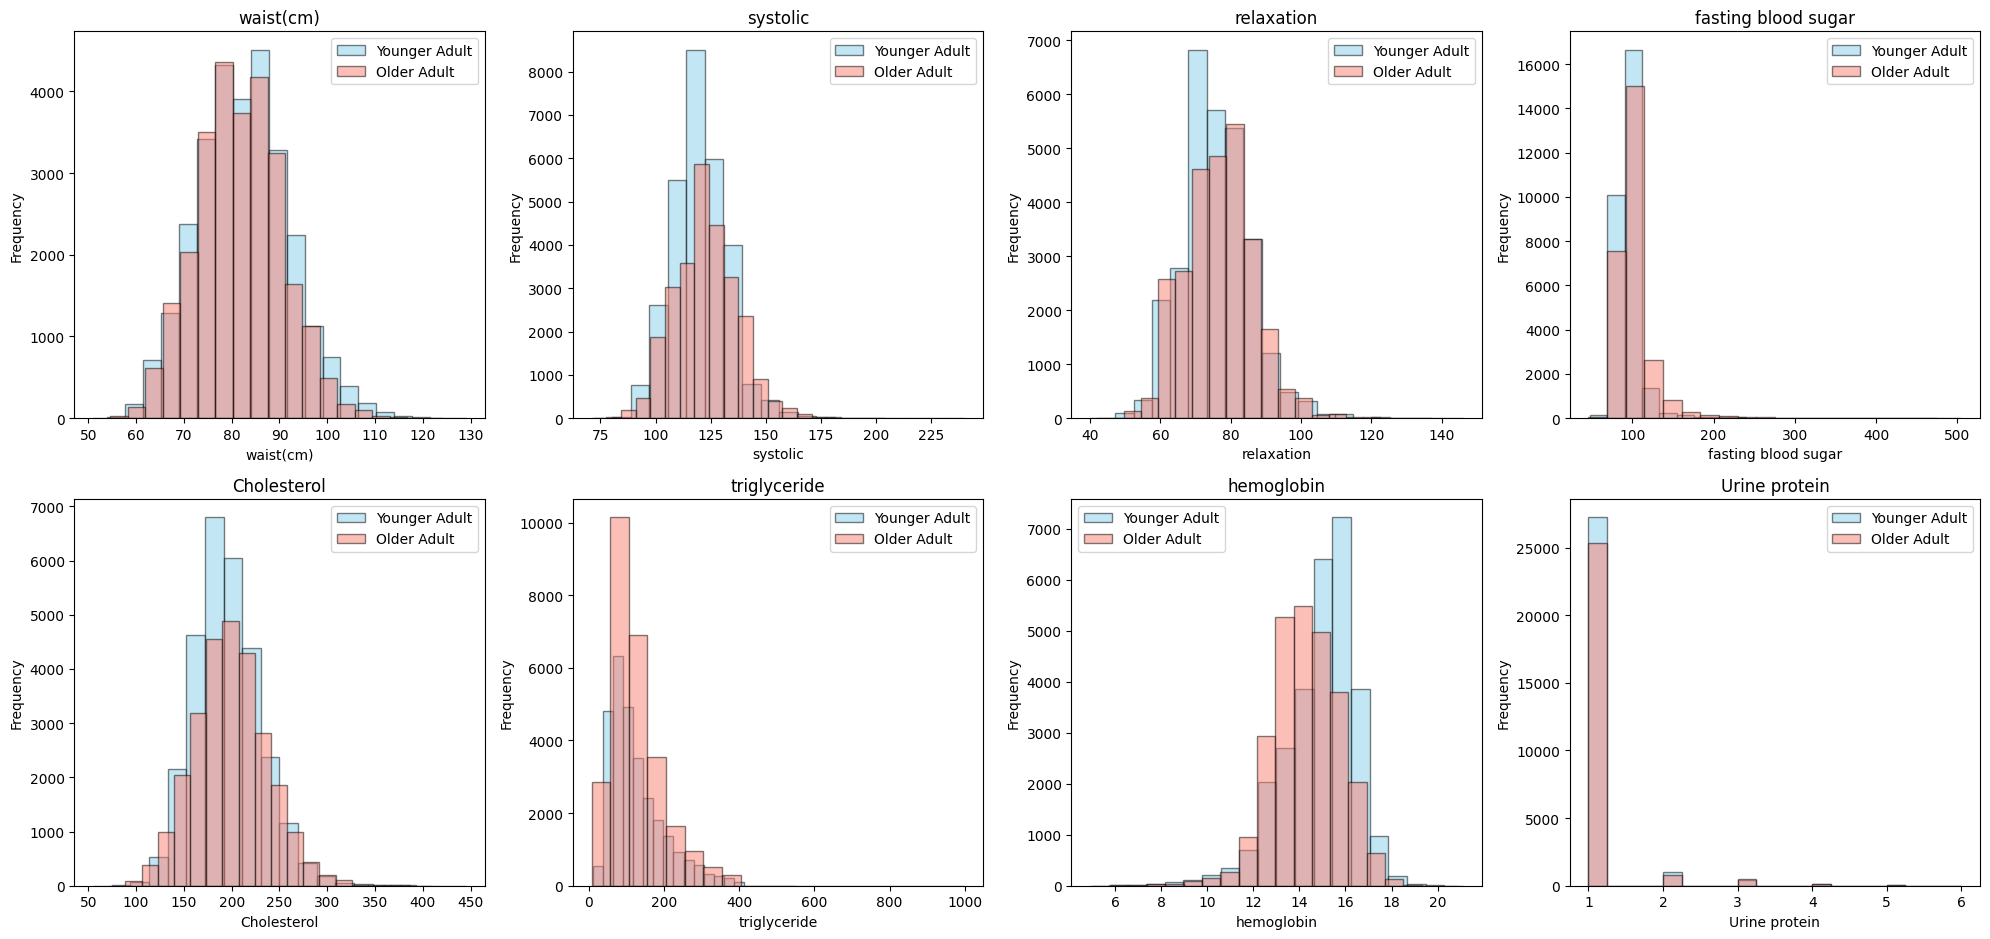

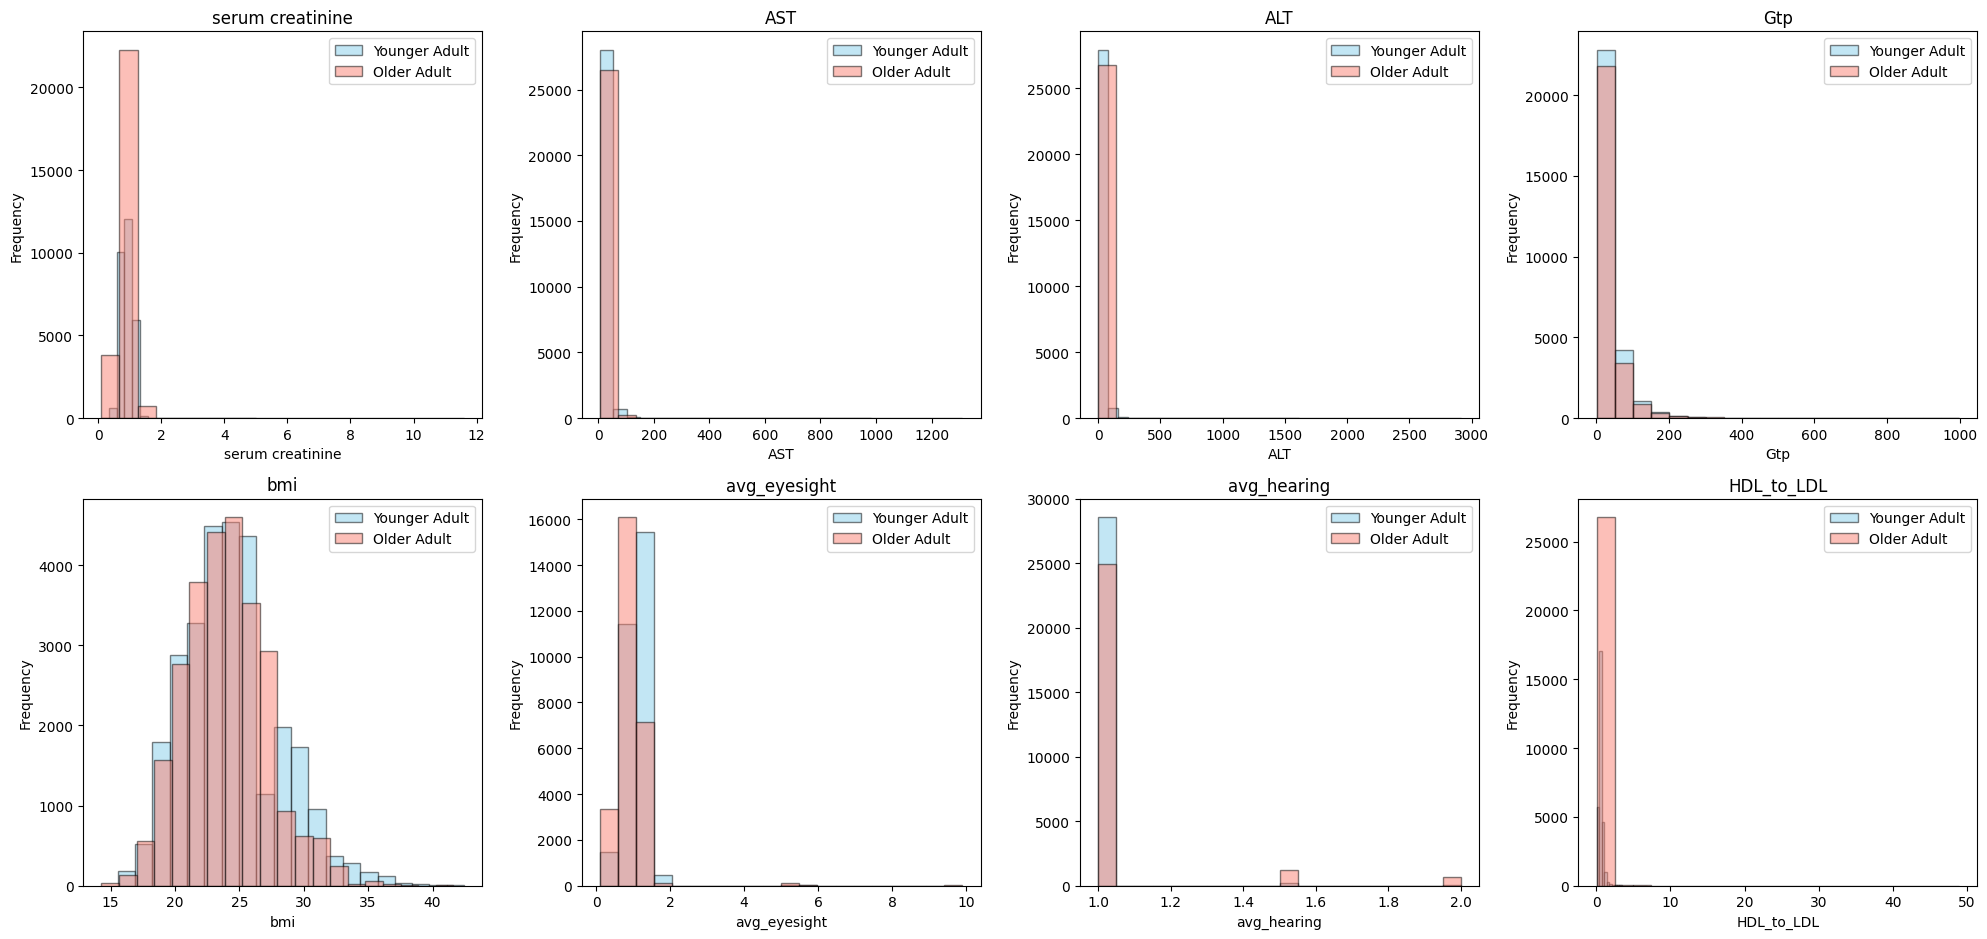

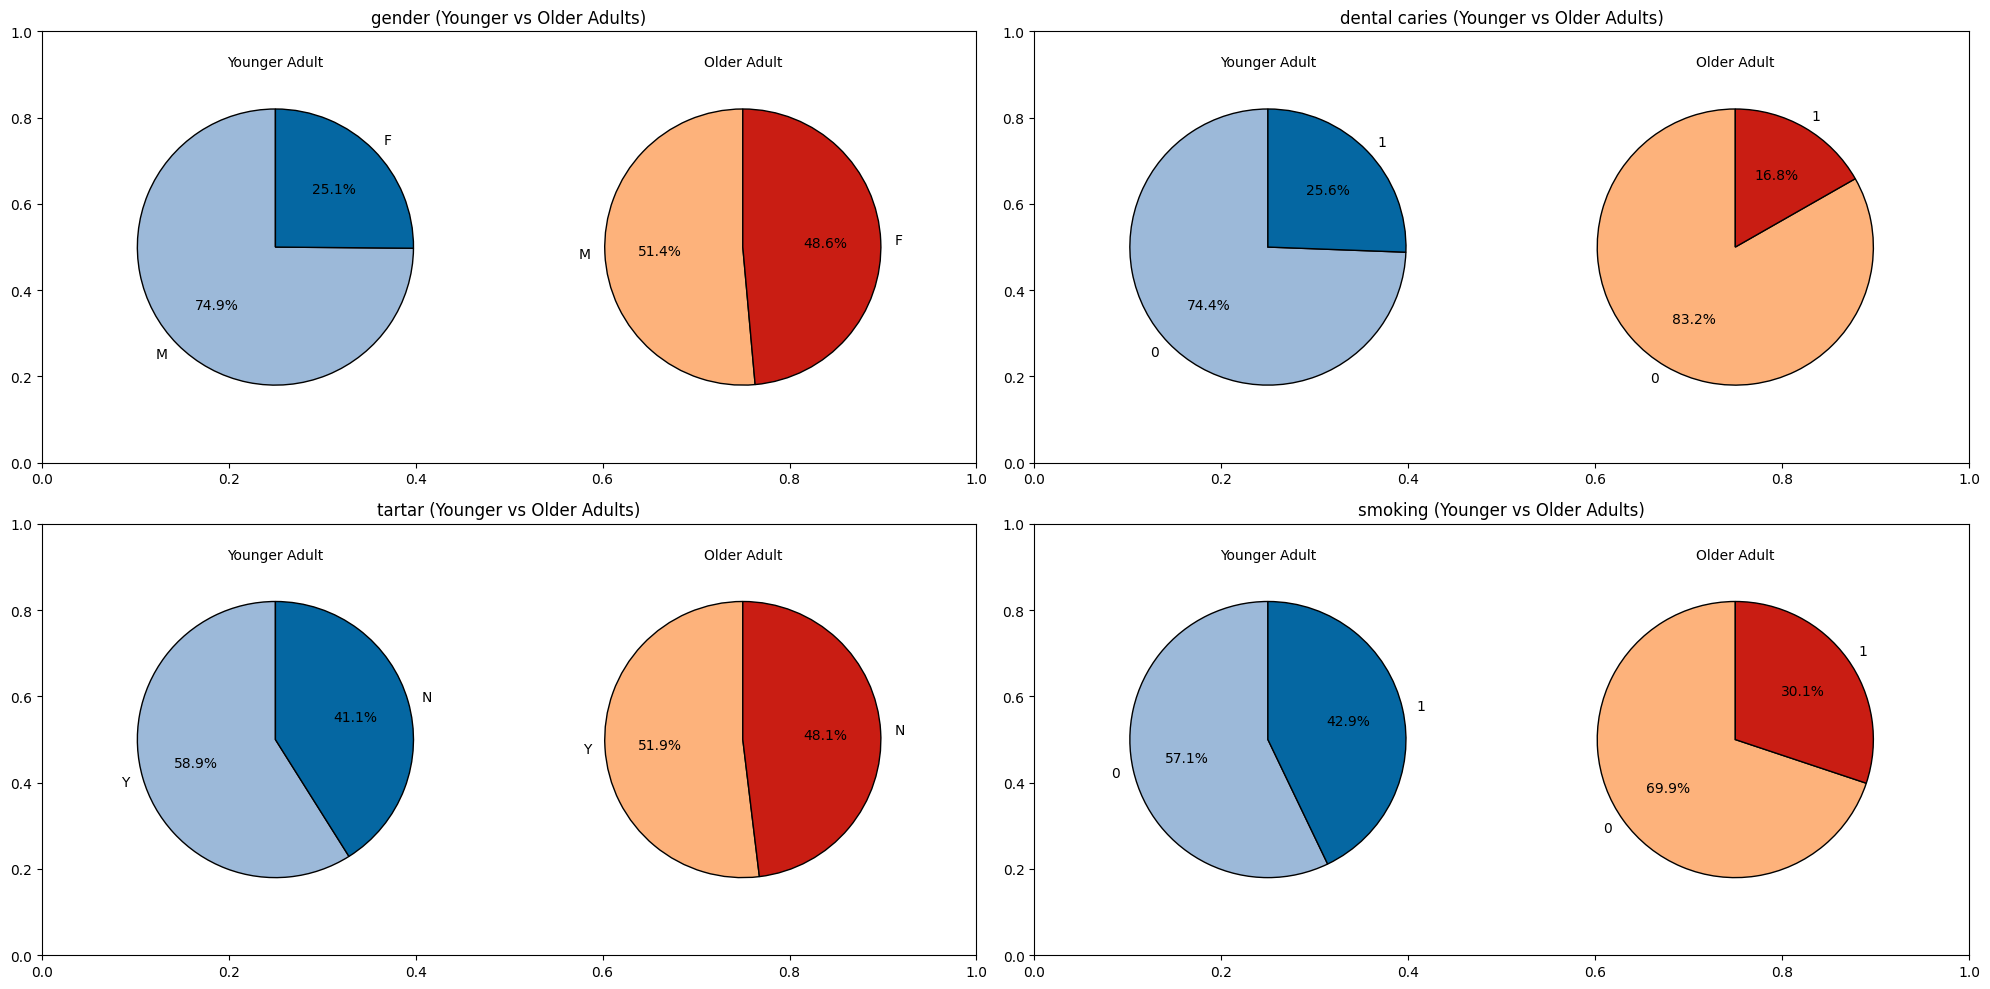

In [17]:
younger_adult = df[(df["age"]>=20)&(df["age"]<=44)]
adult_old = df[(df["age"]>=45)&(df["age"]<=85)]

print(f"{len(younger_adult)} of the participants are 20-44 years old.")
print(f"{len(adult_old)} of the participants are 45-85 years old.")


# Step 4.2.2-a) Numerical features (Age excluded)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "age"]


half = len(numeric_cols) // 2 # Grid layout
first_half = numeric_cols[:half]
second_half = numeric_cols[half:]

def plot_comparison_histogram(columns, group1, group2, group1_name, group2_name): # Helper function: Create comparative histograms
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        axes[i].hist(group1[col].dropna(), bins=20, alpha=0.5, label=group1_name, color='skyblue', edgecolor='black')
        axes[i].hist(group2[col].dropna(), bins=20, alpha=0.5, label=group2_name, color='salmon', edgecolor='black')
        axes[i].set_title(f"{col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
        axes[i].legend()

   
    for j in range(i + 1, len(axes)): # Delete irrelevant subplot
        fig.delaxes(axes[j])

    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_comparison_histogram(first_half, younger_adult, adult_old, "Younger Adult", "Older Adult") # Plot 1: First 8 features
plot_comparison_histogram(second_half, younger_adult, adult_old, "Younger Adult", "Older Adult") # Plot 2: Last 8 features


# Step 4.2.2-b) Categorical features (ID excluded)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["ID"]]


n_cols = 2 # 2x2 grid layout
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 10, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts_young = younger_adult[col].value_counts(normalize=True)
    counts_old = adult_old[col].value_counts(normalize=True)

    ax = axes[i]
    ax.set_title(f"{col} (Younger vs Older Adults)")

    # Subplots
    inner_ax1 = ax.inset_axes([0.05, 0.1, 0.4, 0.8])
    inner_ax2 = ax.inset_axes([0.55, 0.1, 0.4, 0.8])

    inner_ax1.pie(counts_young, labels=counts_young.index, autopct='%1.1f%%',
                  startangle=90, colors=plt.cm.PuBu(np.linspace(0.4, 0.8, len(counts_young))),
                  wedgeprops={'edgecolor': 'black'})
    inner_ax1.set_title("Younger Adult", fontsize=10)

    inner_ax2.pie(counts_old, labels=counts_old.index, autopct='%1.1f%%',
                  startangle=90, colors=plt.cm.OrRd(np.linspace(0.4, 0.8, len(counts_old))),
                  wedgeprops={'edgecolor': 'black'})
    inner_ax2.set_title("Older Adult", fontsize=10)

for j in range(i + 1, len(axes)): # Delete the irrelevant subplot.
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### Smoking-Based Analysis (Non-Smokers vs Smokers)

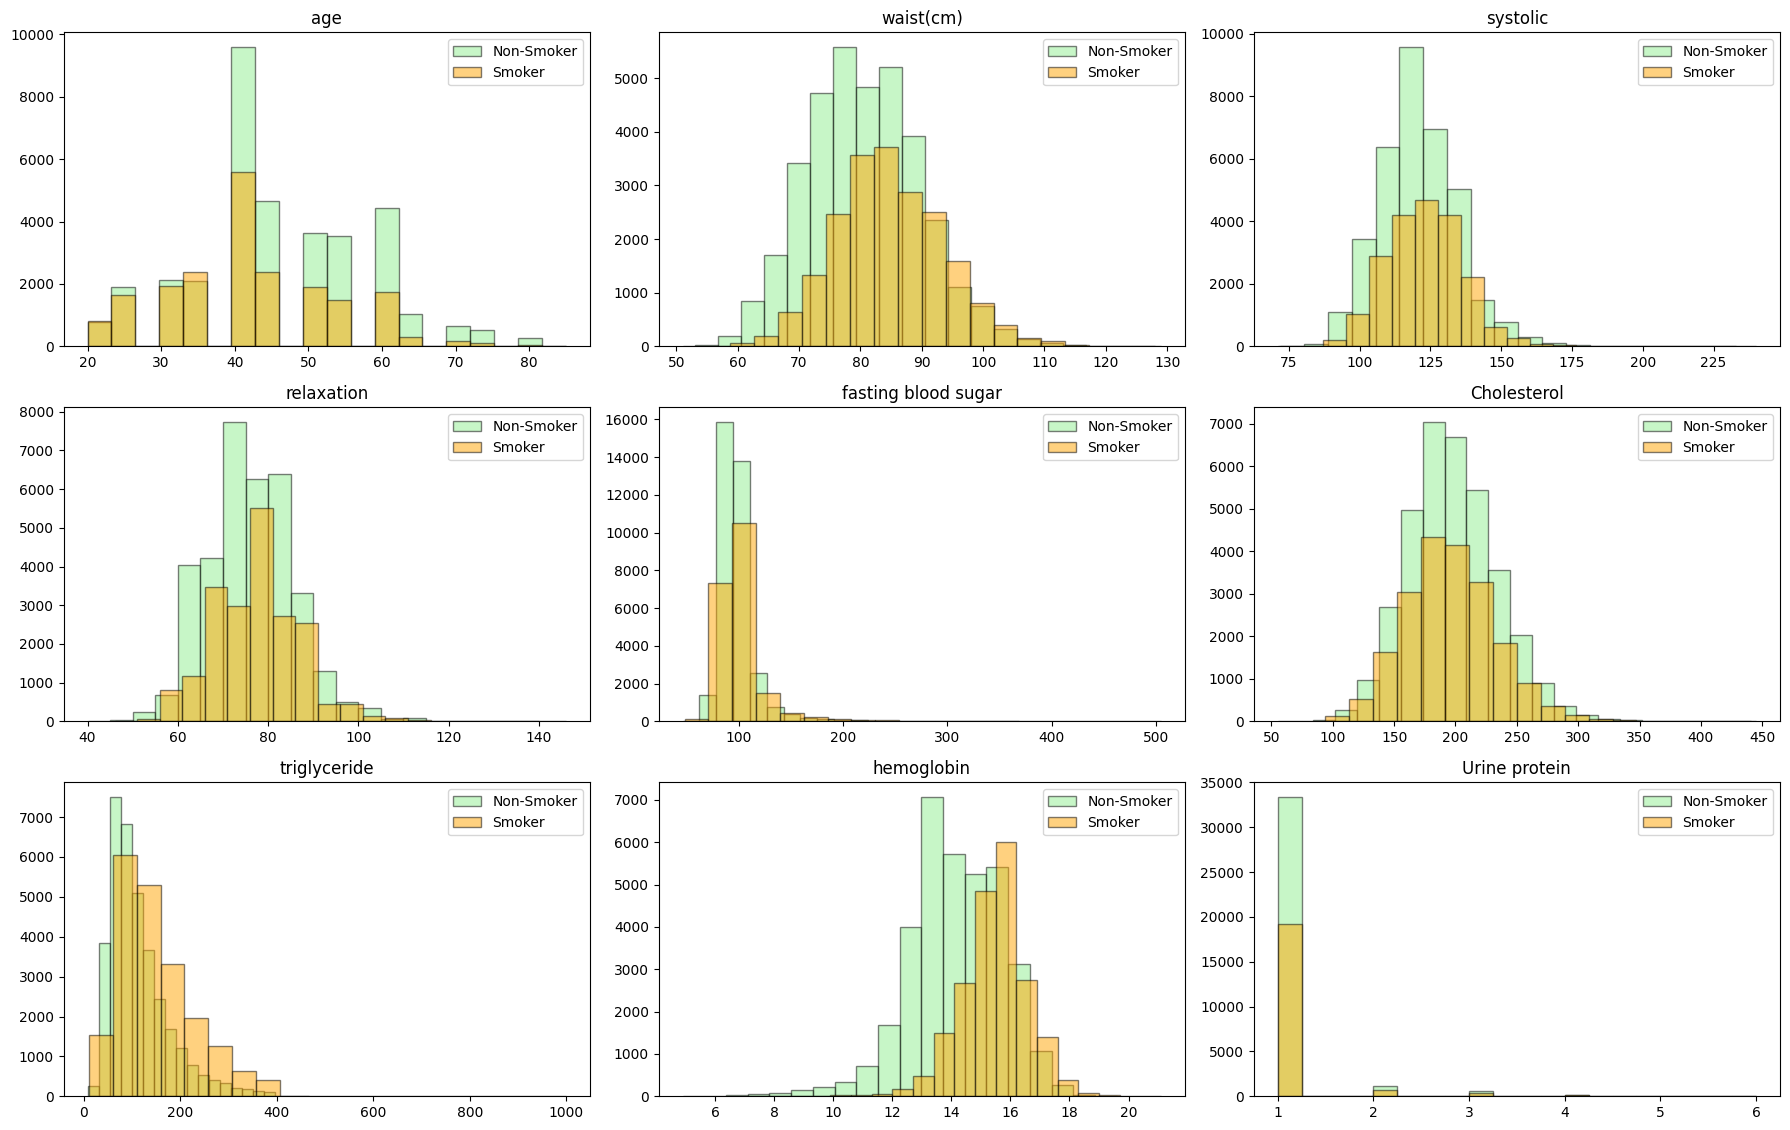

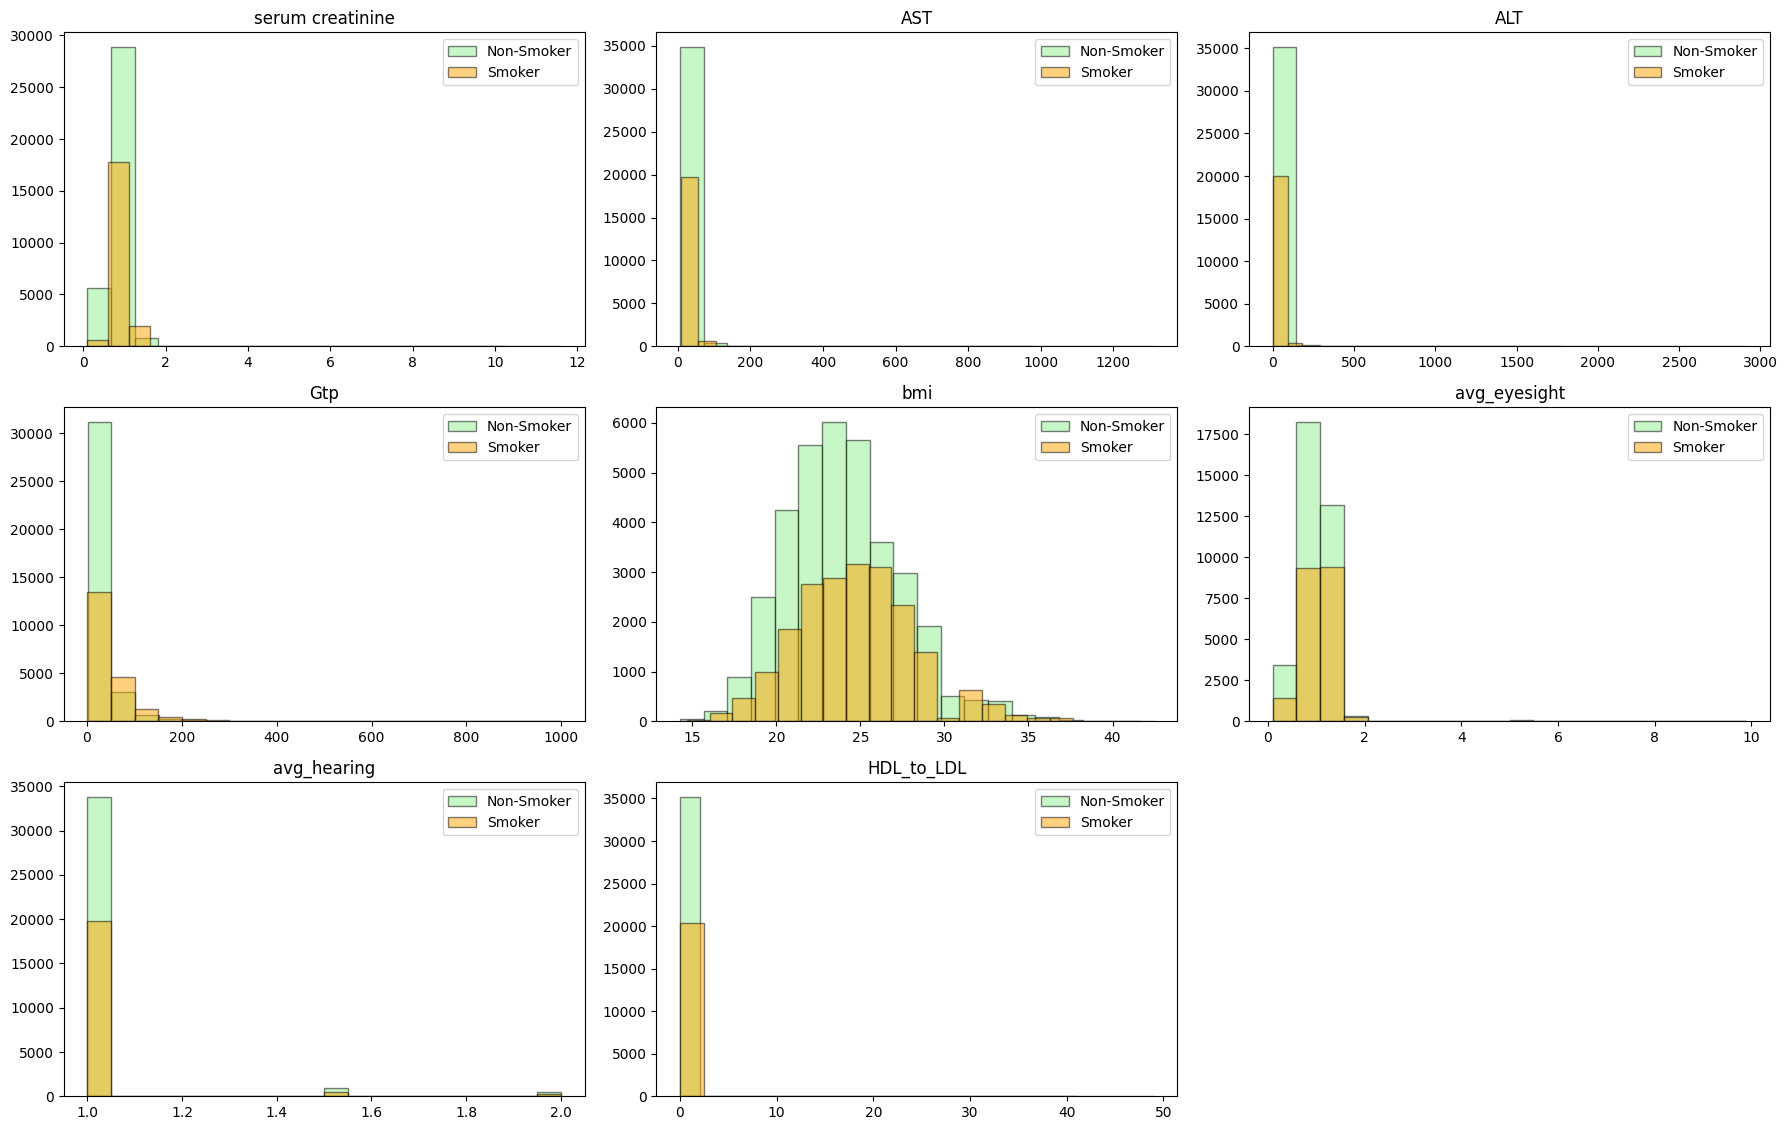

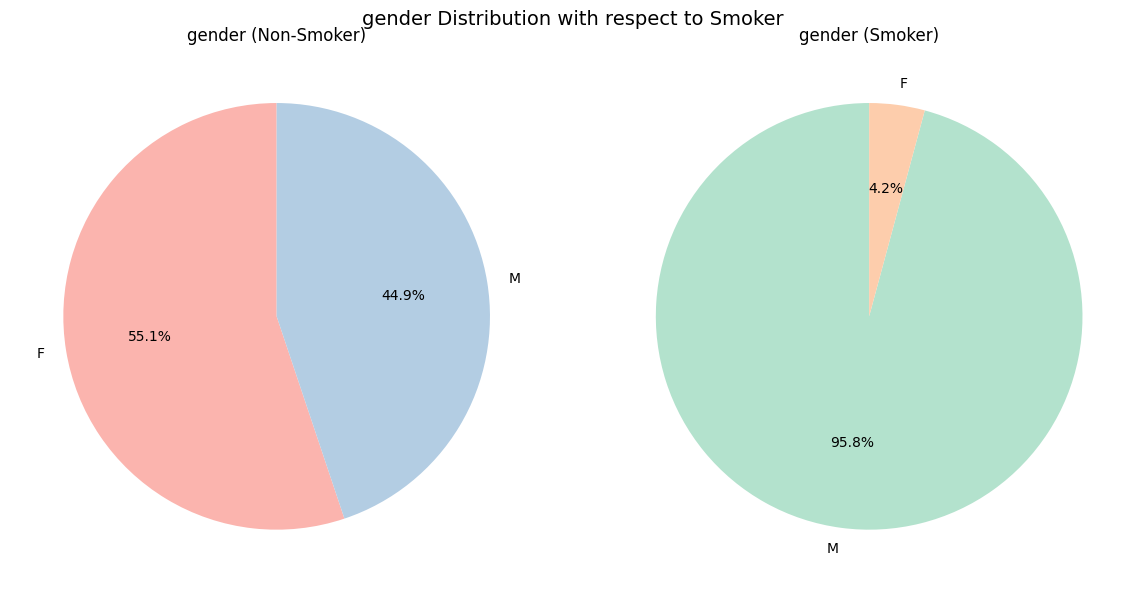

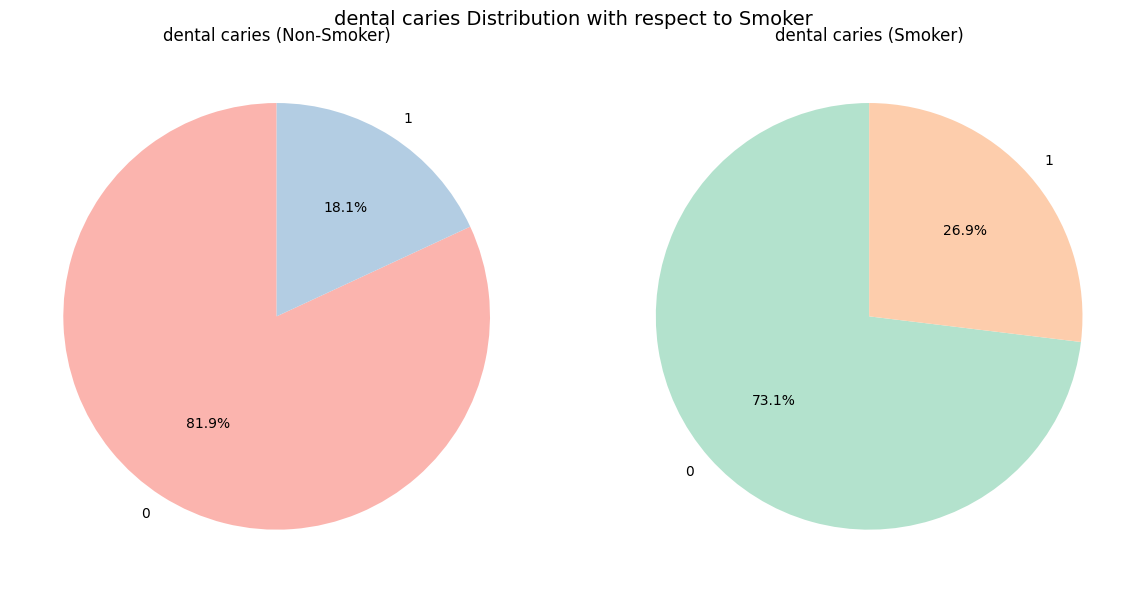

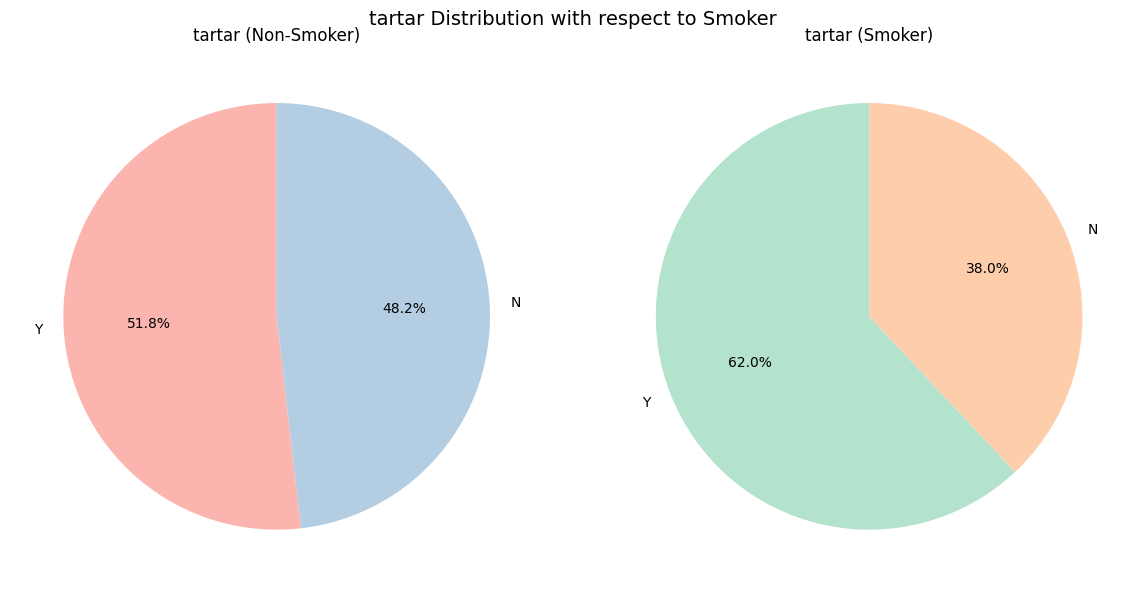

In [18]:
smoking_0 = df[df["smoking"]=="0"]
smoking_1 = df[df["smoking"]=="1"]

# Step 4.2.3-a: Numerical features
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

half = (len(numeric_cols) // 2) + 1 # 2 grids
first_half = numeric_cols[:half]
second_half = numeric_cols[half:]


def plot_comparison_histogram(columns, group1, group2, group1_name, group2_name): # Helper function: Create comparative histograms
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        axes[i].hist(group1[col].dropna(), bins=20, alpha=0.5, label=group1_name, color='lightgreen', edgecolor='black')
        axes[i].hist(group2[col].dropna(), bins=20, alpha=0.5, label=group2_name, color='orange', edgecolor='black')
        axes[i].set_title(f"{col}")
        axes[i].legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_comparison_histogram(first_half, smoking_0, smoking_1, "Non-Smoker", "Smoker") # First grid
plot_comparison_histogram(second_half, smoking_0, smoking_1, "Non-Smoker", "Smoker") # Second grid

# Step 4.2.3-b) Categorical features

categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["ID","smoking"]]
# Pie chart comparison
for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    smoking_0[col].value_counts().plot(kind="pie", ax=axes[0], autopct="%1.1f%%", startangle=90, colors=plt.cm.Pastel1.colors)
    axes[0].set_title(f"{col} (Non-Smoker)")
    axes[0].set_ylabel("")

    smoking_1[col].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90, colors=plt.cm.Pastel2.colors)
    axes[1].set_title(f"{col} (Smoker)")
    axes[1].set_ylabel("")

    plt.suptitle(f"{col} Distribution with respect to Smoker", fontsize=14)
    plt.tight_layout()
    plt.show()

#### Final Evaluation and Insights

Visualizations revealed several noteworthy trends. A significant portion of the participants have liver enzyme levels (AST, ALT, GTP) within the healthy reference ranges, suggesting overall liver health is maintained in most cases. However, when isolating smokers, deviations in GTP levels become more prominent, hinting at potential liver stress.

Similarly, the BMI distribution showed a wide spread, with a non-negligible proportion of participants exceeding healthy thresholds. The HDL-to-LDL ratio was used as a proxy for cardiovascular health, and results indicate that more than half of the population may be at risk due to suboptimal cholesterol balance.

These insights offer a foundation for further analysis—particularly in identifying at-risk groups or predicting health outcomes based on lifestyle factors like smoking. The dataset is now clean, enriched, and ready for statistical modeling or machine learning applications.